In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 74.2 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [3]:
import pdfplumber
import pandas as pd
import numpy as np

In [4]:


file_path = "/content/drive/MyDrive/mapinskhu(26~)/Data/26-2/26-2_extract.pdf"

# {페이지번호: [가져올 테이블 인덱스 리스트]}
target_config = {
    1: [0,1],
    2: [0,1],
    3:[0],
    4:[0,1,2],
    5:[0,1,2],
    6:[0,1,2],
    7:[0,1,2],
    8:[0,1],
    9:[0,1,2],
    10:[0,1,2],
    11:[0,1],
    12:[0,1,2],
    13:[0,1,2],
    14:[0,1,2,3],
    15:[2],
    16:[0],
    17:[0],
    18:[0],
    19:[0],
    20:[0],
    21:[0],
    22:[0],
    23:[0],
    24:[0],
    25:[0],
    26:[0],
    27:[0],
    28:[1],
    29:[0],
    30:[1],
    31:[1],
    32:[1],
    33:[0],
    34:[0]
}

all_selected_tables = []

with pdfplumber.open(file_path) as pdf:
    for page_num, indices in target_config.items():
        try:
            # pdfplumber는 0부터 시작하므로 page_num - 1 사용
            page = pdf.pages[page_num - 1]
            tables = page.extract_tables()

            if not tables:
                print(f"{page_num}페이지에 추출된 테이블이 없습니다.")
                continue

            for idx in indices:
                if len(tables) > idx:
                    raw_table = tables[idx]

                    # 리스트 데이터를 데이터프레임으로 변환
                    # 첫 번째 행을 헤더(columns)로 사용
                    df = pd.DataFrame(raw_table[1:], columns=raw_table[0])

                    all_selected_tables.append(df)
                    print(f"{page_num}페이지의 {idx}번 테이블 추출 성공")
                else:
                    print(f"{page_num}페이지에 {idx}번 인덱스 테이블이 없습니다. (현재 {len(tables)}개 존재)")

        except IndexError:
            print(f"{page_num}페이지가 PDF 전체 범위를 벗어납니다.")

# 추출된 모든 테이블을 하나로 합치고 싶다면 아래 주석을 해제하세요.
# final_df = pd.concat(all_selected_tables, ignore_index=True)

1페이지의 0번 테이블 추출 성공
1페이지의 1번 테이블 추출 성공
2페이지의 0번 테이블 추출 성공
2페이지의 1번 테이블 추출 성공
3페이지의 0번 테이블 추출 성공
4페이지의 0번 테이블 추출 성공
4페이지의 1번 테이블 추출 성공
4페이지의 2번 테이블 추출 성공
5페이지의 0번 테이블 추출 성공
5페이지의 1번 테이블 추출 성공
5페이지의 2번 테이블 추출 성공
6페이지의 0번 테이블 추출 성공
6페이지의 1번 테이블 추출 성공
6페이지의 2번 테이블 추출 성공
7페이지의 0번 테이블 추출 성공
7페이지의 1번 테이블 추출 성공
7페이지의 2번 테이블 추출 성공
8페이지의 0번 테이블 추출 성공
8페이지의 1번 테이블 추출 성공
9페이지의 0번 테이블 추출 성공
9페이지의 1번 테이블 추출 성공
9페이지의 2번 테이블 추출 성공
10페이지의 0번 테이블 추출 성공
10페이지의 1번 테이블 추출 성공
10페이지의 2번 테이블 추출 성공
11페이지의 0번 테이블 추출 성공
11페이지의 1번 테이블 추출 성공
12페이지의 0번 테이블 추출 성공
12페이지의 1번 테이블 추출 성공
12페이지의 2번 테이블 추출 성공
13페이지의 0번 테이블 추출 성공
13페이지의 1번 테이블 추출 성공
13페이지의 2번 테이블 추출 성공
14페이지의 0번 테이블 추출 성공
14페이지의 1번 테이블 추출 성공
14페이지의 2번 테이블 추출 성공
14페이지의 3번 테이블 추출 성공
15페이지의 2번 테이블 추출 성공
16페이지의 0번 테이블 추출 성공
17페이지의 0번 테이블 추출 성공
18페이지의 0번 테이블 추출 성공
19페이지의 0번 테이블 추출 성공
20페이지의 0번 테이블 추출 성공
21페이지의 0번 테이블 추출 성공
22페이지의 0번 테이블 추출 성공
23페이지의 0번 테이블 추출 성공
24페이지의 0번 테이블 추출 성공
25페이지의 0번 테이블 추출 성공
26페이지의 0번 테이블 추출 성공
27페이지의 0번 테이블 추출 성공
28페이지의 1번 테이블 추출 성공
29

In [5]:
all_selected_tables

[  순번 이수\n구분 개설\n학년     과목코드  분반   교과목명 학점  교수명 학년\n제한 전공\n제한  \
 0  1     교필      1  AC00007  01  인권과평화  2  강성현      Y      Y   
 1  2     교필      1  AC00007  02  인권과평화  2  김기명      Y      Y   
 2  3     교필      1  AC00007  03  인권과평화  2  이기웅      Y      Y   
 3  4     교필      1  AC00007  04  인권과평화  2  오영숙      Y      Y   
 4  5     교필      1  AC00007  05  인권과평화  2  김향수      Y      Y   
 5  6     교필      1  AC00007  06  인권과평화  2  김현준      Y      Y   
 
                  강의실/시간                        확인사항  
 0  7207/금요일/10:00~11:50                  주제: 전쟁과 평화  
 1  7308/금요일/10:00~11:50            주제: 한국 인권평화운동 탐구  
 2  M205/금요일/10:00~11:50                  주제: 인권과 공감  
 3  3402/금요일/10:00~11:50        주제: 글로벌 스크린으로 보는\n인권  
 4  7208/금요일/10:00~11:50  주제: 몸의 다양성(젠더,\n질병·장애)과 인권  
 5  3502/금요일/10:00~11:50             주제: 플랫폼노동과 정보인권  ,
   순번 이수\n구분 개설\n학년     과목코드  분반 교과목명 학점  교수명 학년\n제한 전공\n제한  \
 0  1     교필      1  AC00013  01  말과글  2  오현화      Y      Y   
 1  2     교필      1  AC00013  0

In [6]:
processed_tables = []

for df in all_selected_tables:

    # 공통 열 추출
    common_columns = ['이수\n구분', '과목코드', '교과목명', '교수명', '강의실/시간', '확인사항']
    available_cols = [col for col in common_columns if col in df.columns]

    df_final = df[available_cols].copy()
    processed_tables.append(df_final)

# 최종 병합
if processed_tables:
    final_df = pd.concat(processed_tables, ignore_index=True)
    print("병합 완료!")

병합 완료!


In [7]:
final_df[30:50]

,이수\n구분,과목코드,교과목명,교수명,강의실/시간,확인사항
30,교필,AK00183,전공진로세미나,윤영도,7303/금요일/13:00~13:50,인문융합3반
31,교필,AK00183,전공진로세미나,송재민,7301/금요일/14:00~14:50,경영1반
32,교필,AK00183,전공진로세미나,김용미,7302/금요일/14:00~14:50,경영2반
33,교필,AK00183,전공진로세미나,황준서,7303/금요일/14:00~14:50,사회융합1반
34,교필,AK00183,전공진로세미나,이상철,7305/금요일/14:00~14:50,사회융합2반
35,교필,AK00183,전공진로세미나,김태경,7306/금요일/14:00~14:50,사회융합3반
36,교필,AK00183,전공진로세미나,최정태,7304/금요일/14:00~14:50,사회융합4반
37,교필,AK00183,전공진로세미나,윤장열,7305/금요일/13:00~13:50,미디어융합1반
38,교필,AK00183,전공진로세미나,이원정,7306/금요일/13:00~13:50,미디어융합2반
39,교필,AK00183,전공진로세미나,오세현,7304/금요일/13:00~13:50,미디어융합3반


In [8]:
# 특정 행만 컬럼끼리 이어 붙이기
# 데이터가 문자열인지 확인하기 위해 astype(str)을 사용합니다.

target_col = '교과목명'  # 값이 '인평'인지 확인할 컬럼
data_col = '확인사항'    # 가져와서 붙일 내용이 있는 컬럼

# 조건
condition1 = (final_df[target_col] == '인권과평화')
condition2 = (final_df[target_col] == '전공진로세미나')
condition3 = (final_df[target_col] == '자유전공팀세미나')
condition4 = (final_df[target_col] == '디지털리터러시')

# 이어 붙이기
final_df.loc[condition1, target_col] = (
    final_df.loc[condition1, target_col].astype(str) + "(" +
    final_df.loc[condition1, data_col].astype(str) + ")"
)
final_df.loc[condition2, target_col] = (
    final_df.loc[condition2, target_col].astype(str) + "(" +
    final_df.loc[condition2, data_col].astype(str) + ")"
)
final_df.loc[condition3, target_col] = (
    final_df.loc[condition3, target_col].astype(str) + "(" +
    final_df.loc[condition3, data_col].astype(str) + ")"
)
final_df.loc[condition4, target_col] = (
    final_df.loc[condition4, target_col].astype(str) + "(" +
    final_df.loc[condition4, data_col].astype(str) + ")"
)

In [9]:
final_df = final_df.drop(columns=['확인사항'])

In [10]:
final_df.columns = ['kind', 'code', 'class_name', 'prof', 'roomntime']

In [11]:
final_df

,kind,code,class_name,prof,roomntime
0,교필,AC00007,인권과평화(주제: 전쟁과 평화),강성현,7207/금요일/10:00~11:50
1,교필,AC00007,인권과평화(주제: 한국 인권평화운동 탐구),김기명,7308/금요일/10:00~11:50
2,교필,AC00007,인권과평화(주제: 인권과 공감),이기웅,M205/금요일/10:00~11:50
3,교필,AC00007,인권과평화(주제: 글로벌 스크린으로 보는\n인권),오영숙,3402/금요일/10:00~11:50
4,교필,AC00007,"인권과평화(주제: 몸의 다양성(젠더,\n질병·장애)과 인권)",김향수,7208/금요일/10:00~11:50
...,...,...,...,...,...
413,전선,IS00044,인공지능,이상욱,6206/월/12:00~13:15\n6206/수/12:00~13:15
414,전선,IS00045,통계자료분석및실습,윤명호,3302/월/09:00~11:50
415,전선,IS00046,프론트엔드프레임워크,이승진,6202/월/13:30~14:45\n6202/수/13:30~14:45
416,전선,IS00047,빅데이터응용,차현정,6201/금/15:00~17:50


# -------여기까지ㅣ-------

#데이터 가공

##주2회 수업 분리

In [68]:
# 값에서 공백제거
df1 = final_df.copy()

# \s+ 는 모든 공백 문자(스페이스, 탭, 줄바꿈 등)를 의미합니다.
# 이를 빈 문자열('')로 치환하면 문자열 내 모든 공백이 사라집니다.
# df1 = df1.replace({r'\s+': ''}, regex=True)

cols_to_fix = ['kind','code','class_name','prof']

for col in cols_to_fix:
    if col in df1.columns:
        # 모든 공백 문자를 찾아 삭제합니다.
        df1[col] = df1[col].astype(str).str.replace(r'\s+', '', regex=True)

In [76]:
#강의실은 스페이스 문자만 제거
df1['roomntime'] = df1['roomntime'].astype(str).str.replace(' ', '', regex=True)

In [77]:
df2 = df1.copy()
df2['roomntime1'] = df2.roomntime.str.split('\n').str[0]
df2['roomntime2'] = df2.roomntime.str.split('\n').str[1]
df2.drop(columns=['roomntime'], inplace=True)

In [78]:
df2

,kind,code,class_name,prof,roomntime1,roomntime2
0,교필,AC00007,인권과평화(주제:전쟁과평화),강성현,7207/금요일/10:00~11:50,NaN
1,교필,AC00007,인권과평화(주제:한국인권평화운동탐구),김기명,7308/금요일/10:00~11:50,NaN
2,교필,AC00007,인권과평화(주제:인권과공감),이기웅,M205/금요일/10:00~11:50,NaN
3,교필,AC00007,인권과평화(주제:글로벌스크린으로보는인권),오영숙,3402/금요일/10:00~11:50,NaN
4,교필,AC00007,"인권과평화(주제:몸의다양성(젠더,질병·장애)과인권)",김향수,7208/금요일/10:00~11:50,NaN
...,...,...,...,...,...,...
413,전선,IS00044,인공지능,이상욱,6206/월/12:00~13:15,6206/수/12:00~13:15
414,전선,IS00045,통계자료분석및실습,윤명호,3302/월/09:00~11:50,NaN
415,전선,IS00046,프론트엔드프레임워크,이승진,6202/월/13:30~14:45,6202/수/13:30~14:45
416,전선,IS00047,빅데이터응용,차현정,6201/금/15:00~17:50,NaN


##강의실, 요일, 시간 분리

In [79]:
# 주2회 수업중 각 수업의 시간과 강의실이 같은지 확인
# rnt2가 nan인 데이터 제외 추출
df3 = df2.dropna(axis=0, how='any', subset=['roomntime2'], inplace=False).copy()

In [80]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78 entries, 100 to 415
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   kind        78 non-null     object
 1   code        78 non-null     object
 2   class_name  78 non-null     object
 3   prof        78 non-null     object
 4   roomntime1  78 non-null     object
 5   roomntime2  78 non-null     object
dtypes: object(6)
memory usage: 4.3+ KB


In [81]:
df3.head()

,kind,code,class_name,prof,roomntime1,roomntime2
100,교선,AD00003,기초일본어,요코야마나호코,1505/월/13:30~14:45,1505/수/13:30~14:45
101,교선,AD00004,실용일본어,요코야마나호코,1505/월/12:00~13:15,1505/수/12:00~13:15
149,전탐,BH00005,네이티브일본어회화,요코야마나호코,7202/화/13:30~14:45,7202/목/13:30~14:45
150,전탐,BH00006,쉽게배우는중국어,장엽,7305/화/15:00~16:15,7305/목/15:00~16:15
151,전탐,BH00007,키워드로본오늘의중국,이남주,7306/화/13:30~14:45,7306/목/13:30~14:45


In [82]:
# room1과 room2 또는 time1과 time2가 일치하면 false 저장
df3['testRoom'] = \
(df3.roomntime1.str.split('/').str[0]) \
!= (df3.roomntime2.str.split('/').str[0])

df3['testTime'] = \
(df3.roomntime1.str.split('/').str[2]) \
!= (df3.roomntime2.str.split('/').str[2])

In [83]:
df3.head()

,kind,code,class_name,prof,roomntime1,roomntime2,testRoom,testTime
100,교선,AD00003,기초일본어,요코야마나호코,1505/월/13:30~14:45,1505/수/13:30~14:45,False,False
101,교선,AD00004,실용일본어,요코야마나호코,1505/월/12:00~13:15,1505/수/12:00~13:15,False,False
149,전탐,BH00005,네이티브일본어회화,요코야마나호코,7202/화/13:30~14:45,7202/목/13:30~14:45,False,False
150,전탐,BH00006,쉽게배우는중국어,장엽,7305/화/15:00~16:15,7305/목/15:00~16:15,False,False
151,전탐,BH00007,키워드로본오늘의중국,이남주,7306/화/13:30~14:45,7306/목/13:30~14:45,False,False


In [84]:
column_counts = df3[['testRoom', 'testTime']].sum()

print("--- 컬럼별 True 개수 ---")
print(column_counts)

--- 컬럼별 True 개수 ---
testRoom    0
testTime    0
dtype: int64


## 1) true 존재하는 경우

In [85]:
result = df3[df3['testTime'] == True]
result

,kind,code,class_name,prof,roomntime1,roomntime2,testRoom,testTime


## 2) true 존재하지 않는 경우 --> 이번에는 존재하지 않기에 이걸로 실행

In [86]:
df4 = df2.copy()
df4['room1'] = df4.roomntime1.str.split('/').str[0]
df4['room2'] = df4.roomntime2.str.split('/').str[0]
df4['date1'] = df4.roomntime1.str.split('/').str[1]
df4['date2'] = df4.roomntime2.str.split('/').str[1]
df4['start'] = df4.roomntime1.str.split('/').str[2].str.split('~').str[0]
df4['end'] = df4.roomntime1.str.split('/').str[2].str.split('~').str[1]

In [87]:
df4.drop(columns=['roomntime1','roomntime2'], inplace=True)

In [88]:
df4

,kind,code,class_name,prof,room1,room2,date1,date2,start,end
0,교필,AC00007,인권과평화(주제:전쟁과평화),강성현,7207,NaN,금요일,NaN,10:00,11:50
1,교필,AC00007,인권과평화(주제:한국인권평화운동탐구),김기명,7308,NaN,금요일,NaN,10:00,11:50
2,교필,AC00007,인권과평화(주제:인권과공감),이기웅,M205,NaN,금요일,NaN,10:00,11:50
3,교필,AC00007,인권과평화(주제:글로벌스크린으로보는인권),오영숙,3402,NaN,금요일,NaN,10:00,11:50
4,교필,AC00007,"인권과평화(주제:몸의다양성(젠더,질병·장애)과인권)",김향수,7208,NaN,금요일,NaN,10:00,11:50
...,...,...,...,...,...,...,...,...,...,...
413,전선,IS00044,인공지능,이상욱,6206,6206,월,수,12:00,13:15
414,전선,IS00045,통계자료분석및실습,윤명호,3302,NaN,월,NaN,09:00,11:50
415,전선,IS00046,프론트엔드프레임워크,이승진,6202,6202,월,수,13:30,14:45
416,전선,IS00047,빅데이터응용,차현정,6201,NaN,금,NaN,15:00,17:50


In [89]:
# 특정 열에 어떤 값들이 들어있는지 빈도순으로 확인
# 오타나 빈 칸(공백)이 있다면 여기서 바로 보입니다.
print(df4['room1'].value_counts())
print(df4['room2'].value_counts())

room1
3502     19
7308     15
7309     15
7208     15
6202     14
7107     14
6403     14
7202     13
6201     13
6206     13
7304     13
7616     12
7205     12
7206     12
3402     12
3401     11
7301     11
1504     11
3301     11
7201     10
6406     10
6405     10
7204     10
7207     10
1505      9
7305      9
7306      8
M205      8
B105      8
M401      7
M301      6
3302      6
1503      6
1506      6
9990      6
3501      5
-         5
5C301     4
M402      3
7303      3
M406      3
7307      3
6402      2
6404      2
7302      2
M404      2
None      2
9301      1
6110      1
7706      1
Name: count, dtype: int64
room2
7202    8
6202    8
6201    7
6405    7
7301    6
7309    6
7308    4
6406    4
6206    4
7207    3
7305    3
1505    2
7306    2
7205    2
7206    2
7616    2
3302    2
B105    2
7304    1
7307    1
7204    1
1504    1
Name: count, dtype: int64


## 강의실 없는 강의 삭제

In [90]:
df4[df4['room1']=='-']

,kind,code,class_name,prof,room1,room2,date1,date2,start,end
54,교필,AE00044,농촌봉사,열림교양대학,-,NaN,NaN,NaN,NaN,NaN
368,전선,XE00022,인턴십1,이상윤,-,NaN,NaN,NaN,NaN,NaN
369,전선,XE00023,인턴십2,이상윤,-,NaN,NaN,NaN,NaN,NaN
370,전선,XE00024,인턴십3,이상윤,-,NaN,NaN,NaN,NaN,NaN
371,전선,XE00025,인턴십4,이상윤,-,NaN,NaN,NaN,NaN,NaN


In [115]:
df5 = df4[~(df4['room1']=='-')]

In [116]:
#df5[df5['room1']=='미지정']
#df5[df5['room1']=='9999']

In [117]:
df5[368:375]

,kind,code,class_name,prof,room1,room2,date1,date2,start,end
373,전필,FI00001,머신러닝입문,홍성준,6405,6405,화요일,목요일,16:30,17:45
374,전선,FI00005,고급Python프로그래밍,공준욱,6405,NaN,화요일,NaN,09:00,11:50
375,전선,FI00010,강화학습,이상윤,1503,NaN,금요일,NaN,12:00,14:50
376,전선,FI00011,인공지능수학,곽승우,6405,6405,월요일,수요일,15:00,16:15
377,전선,FI00012,순환신경망과자연어처리,곽승우,6405,6405,월요일,수요일,13:30,14:45
378,전선,FI00013,라이프데이터분석과AI,김수림김양희곽승우,B105,NaN,금요일,NaN,15:00,17:50
379,전선,IS00001,Javascript프로그래밍,이해신,6202,NaN,금,NaN,12:00,14:50


In [118]:
print(df4['start'].value_counts())
print(df4['end'].value_counts())

start
15:00          107
09:00          100
12:00          100
13:30           23
16:30           17
10:00           16
14:00           15
13:00           15
11:00            8
18:25            3
17:00            2
16:00            2
18:00            1
15:00-17:50      1
15:-17:50        1
Name: count, dtype: int64
end
11:50    108
14:50     94
17:50     79
16:15     23
14:45     23
13:50     19
17:45     17
13:15     15
12:50     10
10:50      8
16:50      4
19:15      3
15:50      3
18:50      2
19:50      1
Name: count, dtype: int64


In [119]:
# 'start 컬럼명'에 NaN이 있는 행들만 보기
nan_rows = df5[df5['start'].isna()]
nan_rows

,kind,code,class_name,prof,room1,room2,date1,date2,start,end
119,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN
120,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN


### 확인 해보니 119, 120 행은 잘못 추출된 행인 것으로 보임.

In [120]:

df5[115:121]

,kind,code,class_name,prof,room1,room2,date1,date2,start,end
116,교선,AK00193,생활달리기,미지정(채용중),1503,NaN,수,NaN,09:00,10:50
117,교선,AK00196,모두의그라운드:축구,김동혁,1503,NaN,수,NaN,12:00,13:50
118,교선,AK00080,대학생사회공헌프로젝트2,임정아,M404,NaN,금,NaN,15:00,17:50
119,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN
120,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN
121,교선,AH00022,진로탐색과자기계발,한상진,7208,NaN,화,NaN,15:00,16:50


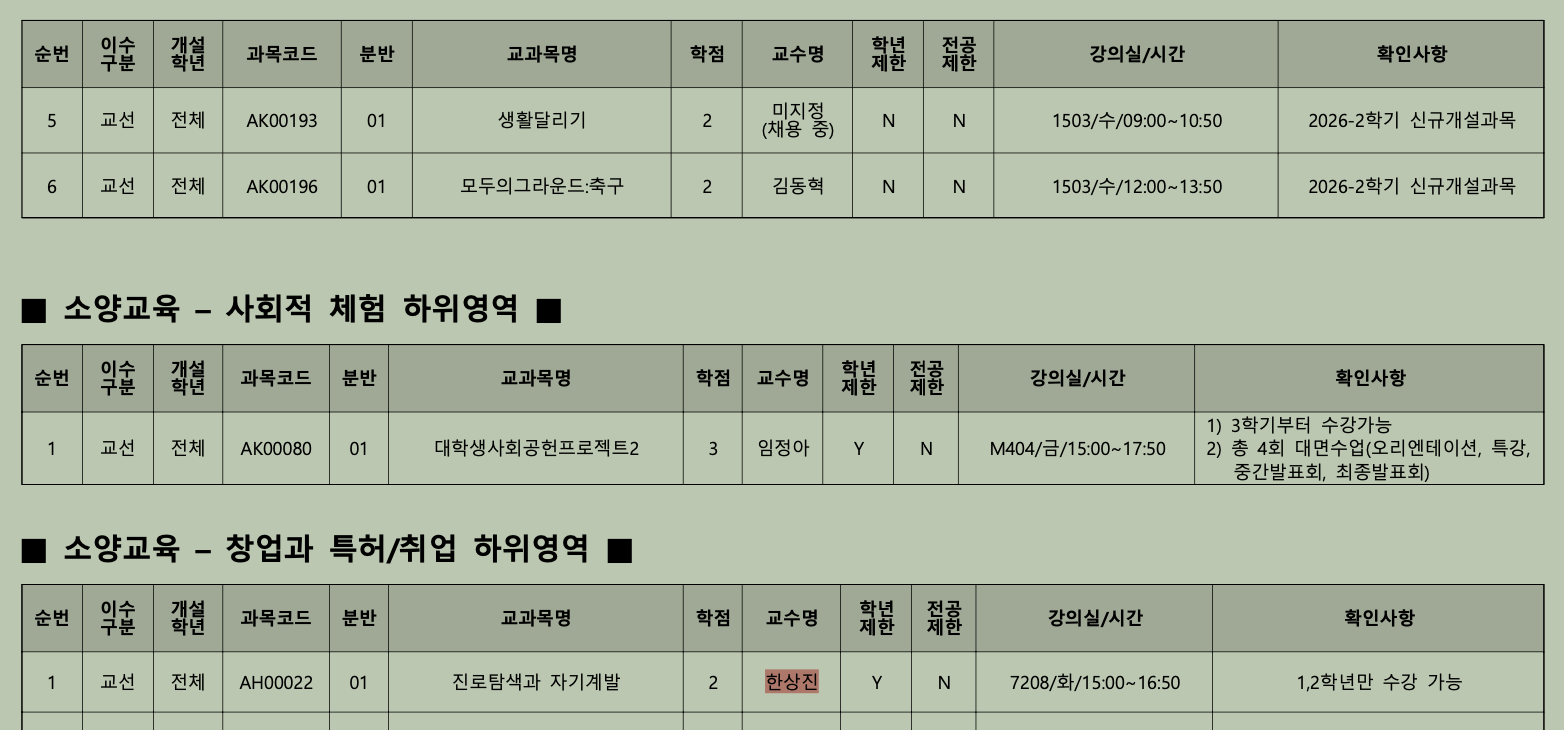

In [121]:
# drop=True: 기존의 꼬인 인덱스를 컬럼으로 만들지 않고 버립니다.
# inplace=True: 원본 데이터를 바로 수정합니다.
df5.reset_index(drop=True, inplace=True)

In [122]:
# 행 삭제
df5 = df5.drop([118, 119])

In [123]:
df5.reset_index(drop=True, inplace=True)

In [133]:
df5[115:121]

,kind,code,class_name,prof,room1,room2,date1,date2,start,end
115,교선,AK00193,생활달리기,미지정(채용중),1503,NaN,수,NaN,09:00,10:50
116,교선,AK00196,모두의그라운드:축구,김동혁,1503,NaN,수,NaN,12:00,13:50
117,교선,AK00080,대학생사회공헌프로젝트2,임정아,M404,NaN,금,NaN,15:00,17:50
118,교선,AH00022,진로탐색과자기계발,한상진,7208,NaN,화,NaN,15:00,16:50
119,교선,AH00056,창업과지식재산,류선미,7208,NaN,화,NaN,10:00,11:50
120,교선,AK00153,직업으로서의시민사회활동,박경주,3301,NaN,월,NaN,12:00,14:50


In [134]:
df6 = df5.copy()

In [135]:
# 'end 컬럼명'에 NaN이 있는 행들만 보기
nan_rows = df6[df6['end'].isna()]
nan_rows

,kind,code,class_name,prof,room1,room2,date1,date2,start,end
341,전선,HR00010,공감,박경태신익상박남기,7201,NaN,화,NaN,15:00-17:50,NaN
351,전선,HR00005,인공지능시대의종교와미디어의미래,최영묵이주엽,7201,NaN,목,NaN,15:-17:50,NaN


강의시간이 ~가 아닌 -로 작성된 행들이 제대로 분리되지 않았음.

In [136]:
# 1. 대상 인덱스 정의
target_indices = [341, 351]

# 2. 원본 데이터를 임시 변수에 저장 (덮어씌워짐 방지)
temp_split = df6.loc[target_indices, 'start'].str.split('-')

# 3. 임시 변수에서 각각 첫 번째와 두 번째 값을 가져와 할당
df6.loc[target_indices, 'start'] = temp_split.str[0]
df6.loc[target_indices, 'end'] = temp_split.str[1]

In [137]:
result = df6.loc[[341, 351]]
result

,kind,code,class_name,prof,room1,room2,date1,date2,start,end
341,전선,HR00010,공감,박경태신익상박남기,7201,NaN,화,NaN,15:00,17:50
351,전선,HR00005,인공지능시대의종교와미디어의미래,최영묵이주엽,7201,NaN,목,NaN,15:,17:50


In [138]:
#인덱스 351은 완전히 이상한 값을 작성하여 주었기에 직접 수정함.
df6.loc[351, 'start'] = '15:00'
result = df6.loc[[341, 351]]
result

,kind,code,class_name,prof,room1,room2,date1,date2,start,end
341,전선,HR00010,공감,박경태신익상박남기,7201,NaN,화,NaN,15:00,17:50
351,전선,HR00005,인공지능시대의종교와미디어의미래,최영묵이주엽,7201,NaN,목,NaN,15:00,17:50


In [140]:
# nan 재확인
nan_rows = df6[df6['end'].isna()]
nan_rows

,kind,code,class_name,prof,room1,room2,date1,date2,start,end


In [141]:
df7 = df6.copy()

time이 콜론으로 분리되지 않은 것 찾기

In [148]:
len(df7)

411

In [146]:

len(df7[df7['start'].str.contains(":") & \
        df7['end'].str.contains(":")])

411

#중복제거

In [149]:
df8 = df7.copy()
df8.reset_index(drop=True, inplace=True)

In [150]:
len(df8)

411

In [156]:
# 1. 모든 컬럼 기준 중복 행 전체 추출 후 정렬
# (중복된 모든 행을 추출하여 나란히 정렬)
duplicate_rows = df8[df8.duplicated(keep=False)].sort_values(by=list(df8.columns))

# 2. 특정 컬럼(예: 'user_id', 'testTime') 기준 중복 행 확인, 'code'로 정렬하여 중복된 행 확인하기
duplicate_rows = df8[df8.duplicated(subset=['code', 'class_name', 'prof', 'room1', 'date1', 'start'], keep=False)].sort_values(by=['code'])

duplicate_rows

,kind,code,class_name,prof,room1,room2,date1,date2,start,end
363,전선,FH00013,라이프데이터분석과AI,김수림김양희곽승우,B105,NaN,금요일,NaN,15:00,17:50
355,전선,FH00013,라이프데이터분석과AI,김수림김양희곽승우,B105,NaN,금요일,NaN,15:00,17:50
366,전필,FI00001,머신러닝입문,홍성준,6405,6405,화요일,목요일,16:30,17:45
358,전필,FI00001,머신러닝입문,홍성준,6405,6405,화요일,목요일,16:30,17:45
359,전선,FI00005,고급Python프로그래밍,공준욱,6405,NaN,화요일,NaN,09:00,11:50
367,전선,FI00005,고급Python프로그래밍,공준욱,6405,NaN,화요일,NaN,09:00,11:50
368,전선,FI00010,강화학습,이상윤,1503,NaN,금요일,NaN,12:00,14:50
360,전선,FI00010,강화학습,이상윤,1503,NaN,금요일,NaN,12:00,14:50
361,전선,FI00011,인공지능수학,곽승우,6405,6405,월요일,수요일,15:00,16:15
369,전선,FI00011,인공지능수학,곽승우,6405,6405,월요일,수요일,15:00,16:15


19개 - 9개 = 10개 제거 예정 --> 411 - 10 = 401

In [157]:
df9 = df8.drop_duplicates(['code', 'class_name', 'prof', 'room1', 'date1', 'start'], keep='first')

In [158]:

len(df9)

401

## 데이터 일관성

date에 '요일'까지 작성된것들 고치기

In [159]:
df10 = df9.copy()

In [160]:
df10['date1'] = df10.date1.str.split('요일').str[0]
df10['date2'] = df10.date2.str.split('요일').str[0]
df10

,kind,code,class_name,prof,room1,room2,date1,date2,start,end
0,교필,AC00007,인권과평화(주제:전쟁과평화),강성현,7207,NaN,금,NaN,10:00,11:50
1,교필,AC00007,인권과평화(주제:한국인권평화운동탐구),김기명,7308,NaN,금,NaN,10:00,11:50
2,교필,AC00007,인권과평화(주제:인권과공감),이기웅,M205,NaN,금,NaN,10:00,11:50
3,교필,AC00007,인권과평화(주제:글로벌스크린으로보는인권),오영숙,3402,NaN,금,NaN,10:00,11:50
4,교필,AC00007,"인권과평화(주제:몸의다양성(젠더,질병·장애)과인권)",김향수,7208,NaN,금,NaN,10:00,11:50
...,...,...,...,...,...,...,...,...,...,...
406,전선,IS00044,인공지능,이상욱,6206,6206,월,수,12:00,13:15
407,전선,IS00045,통계자료분석및실습,윤명호,3302,NaN,월,NaN,09:00,11:50
408,전선,IS00046,프론트엔드프레임워크,이승진,6202,6202,월,수,13:30,14:45
409,전선,IS00047,빅데이터응용,차현정,6201,NaN,금,NaN,15:00,17:50


# 관 컬럼 추가

In [161]:
df11 = df10.copy()

In [162]:
df11['kwan'] = df11['room1'].str[0]

conditionlist = [
    (df11['kwan'] == '1'),
    (df11['kwan'] == '3'),
    (df11['kwan'] == 'M'),
    (df11['kwan'] == '9'),
    (df11['kwan'] == '7'),
    (df11['kwan'] == '6'),
    (df11['kwan'] == 'B'),
    (df11['kwan'] == '5')
] #첫 문자로 관 판별
choicelist = [
    '승연관',
    '월당관',
    '미가엘관',
    '성미가엘성당&피츠버그홀',
    '새천년관',
    '정보과학관',
    '일만관',
    '나눔관'
]

df11['kwan'] = np.select(conditionlist, choicelist, default='미정')

In [163]:
df11

,kind,code,class_name,prof,room1,room2,date1,date2,start,end,kwan
0,교필,AC00007,인권과평화(주제:전쟁과평화),강성현,7207,NaN,금,NaN,10:00,11:50,새천년관
1,교필,AC00007,인권과평화(주제:한국인권평화운동탐구),김기명,7308,NaN,금,NaN,10:00,11:50,새천년관
2,교필,AC00007,인권과평화(주제:인권과공감),이기웅,M205,NaN,금,NaN,10:00,11:50,미가엘관
3,교필,AC00007,인권과평화(주제:글로벌스크린으로보는인권),오영숙,3402,NaN,금,NaN,10:00,11:50,월당관
4,교필,AC00007,"인권과평화(주제:몸의다양성(젠더,질병·장애)과인권)",김향수,7208,NaN,금,NaN,10:00,11:50,새천년관
...,...,...,...,...,...,...,...,...,...,...,...
406,전선,IS00044,인공지능,이상욱,6206,6206,월,수,12:00,13:15,정보과학관
407,전선,IS00045,통계자료분석및실습,윤명호,3302,NaN,월,NaN,09:00,11:50,월당관
408,전선,IS00046,프론트엔드프레임워크,이승진,6202,6202,월,수,13:30,14:45,정보과학관
409,전선,IS00047,빅데이터응용,차현정,6201,NaN,금,NaN,15:00,17:50,정보과학관


# 완성된 데이터프레임 csv 만들기

In [164]:
csv26_2 = df11.copy()

In [165]:
csv26_2.to_csv('csv26_2.csv', index=False, encoding='utf-8-sig')